# US Accidents: Predicting Accident Severity

**Data:** `US_Accidents_March23.csv` (about 7.7 million accidents, 46 columns).

**Goal:** predict the severity of an accident (1 = least impact, 4 = most impact) from the time, place, weather and road features.

**Models:** K-Nearest Neighbours, Logistic Regression and XGBoost.

Run the notebook from top to bottom. It needs the `xgboost` package in addition to the usual data science libraries.

# 1. Exploring the Data

## 1.1 Load the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('US_Accidents_March23.csv')

In [3]:
print(f"Dataset Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset Dimensions: 7728394 rows and 46 columns.



In [4]:
print("Data Types and Non-Null Counts")
df.info()

Data Types and Non-Null Counts
<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22

In [5]:
print("Numerical Feature Statistics")
display(df.describe())

Numerical Feature Statistics


,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


## 1.2 Missing values

In [6]:
missing_counts = df.isna().sum()
missing_percentages = (df.isna().sum() / len(df)) * 100
missing_data_table = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_percentages
})
missing_data_table = missing_data_table[missing_data_table['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)
print("Missing Values Table\n")
display(missing_data_table)

Missing Values Table



,Missing_Count,Missing_Percentage
End_Lat,3402762,44.029355
End_Lng,3402762,44.029355
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524
Wind_Direction,175206,2.267043
Humidity(%),174144,2.253301
Weather_Condition,173459,2.244438
Temperature(F),163853,2.120143


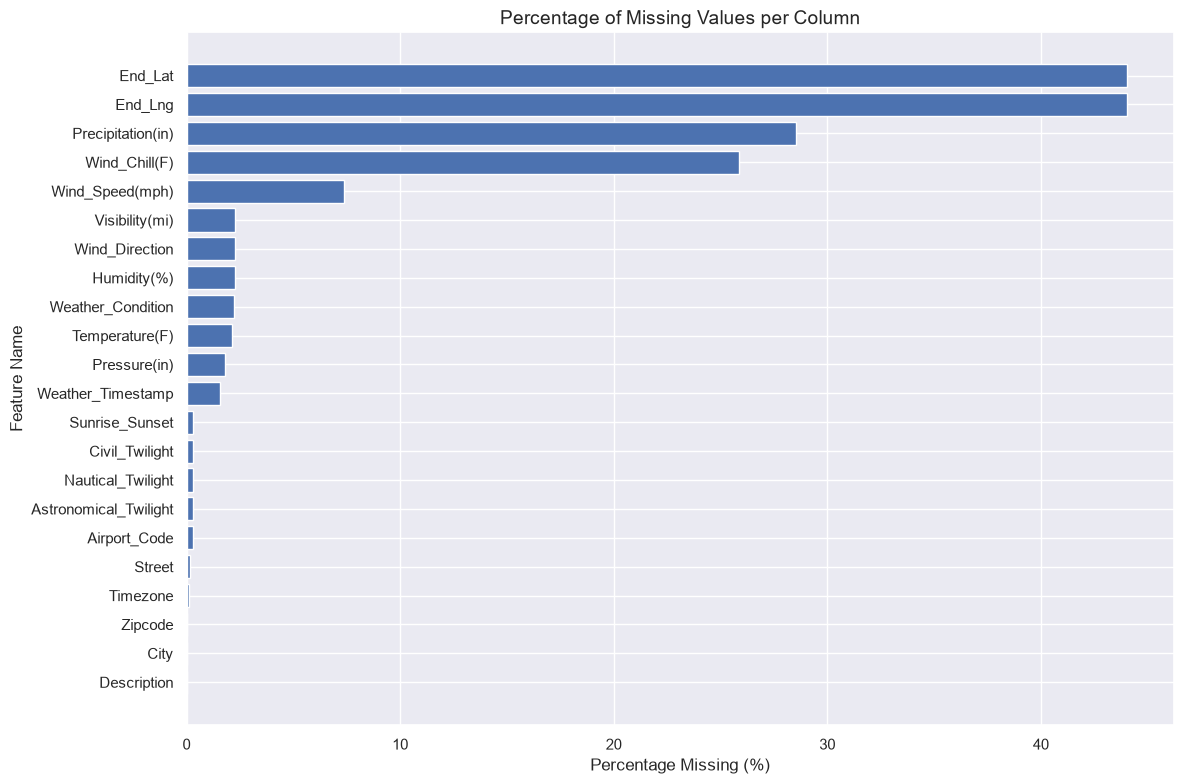

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(missing_data_table))
ax.barh(y_pos, missing_data_table['Missing_Percentage'])

ax.set_yticks(y_pos)
ax.set_yticklabels(missing_data_table.index)
ax.invert_yaxis()

ax.set_title('Percentage of Missing Values per Column', fontsize=14)
ax.set_xlabel('Percentage Missing (%)')
ax.set_ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 1.3 Correlations between numeric columns

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
Severity,1.000000,0.069060,0.052862,0.083724,0.093190,0.034787,-0.020327,-0.070039,0.022293,0.042347,-0.003473,0.040214,0.021080
Start_Lat,0.069060,1.000000,-0.067720,0.999993,-0.121743,0.064064,-0.443781,-0.480296,0.022364,-0.194094,-0.088500,0.032908,0.000279
Start_Lng,0.052862,-0.067720,1.000000,-0.121735,0.999999,0.007851,-0.010652,-0.031810,0.179500,0.193185,-0.015322,0.077353,0.027619
End_Lat,0.083724,0.999993,-0.121735,1.000000,-0.121732,0.067932,-0.468692,-0.489578,0.027849,-0.242143,-0.116199,0.017373,-0.003639
End_Lng,0.093190,-0.121743,0.999999,-0.121732,1.000000,0.005876,0.024084,0.006733,0.167428,0.216028,0.006155,0.092303,0.025536
Distance(mi),0.034787,0.064064,0.007851,0.067932,0.005876,1.000000,-0.054082,-0.044309,0.008780,-0.093121,-0.037225,0.008989,-0.001480
Temperature(F),-0.020327,-0.443781,-0.010652,-0.468692,0.024084,-0.054082,1.000000,0.993744,-0.330939,0.109500,0.217173,0.033750,-0.004633
Wind_Chill(F),-0.070039,-0.480296,-0.031810,-0.489578,0.006733,-0.044309,0.993744,1.000000,-0.314731,0.086598,0.234022,-0.043008,-0.012143
Humidity(%),0.022293,0.022364,0.179500,0.027849,0.167428,0.008780,-0.330939,-0.314731,1.000000,0.115573,-0.384261,-0.172403,0.076936
Pressure(in),0.042347,-0.194094,0.193185,-0.242143,0.216028,-0.093121,0.109500,0.086598,0.115573,1.000000,0.038161,-0.022609,0.016511


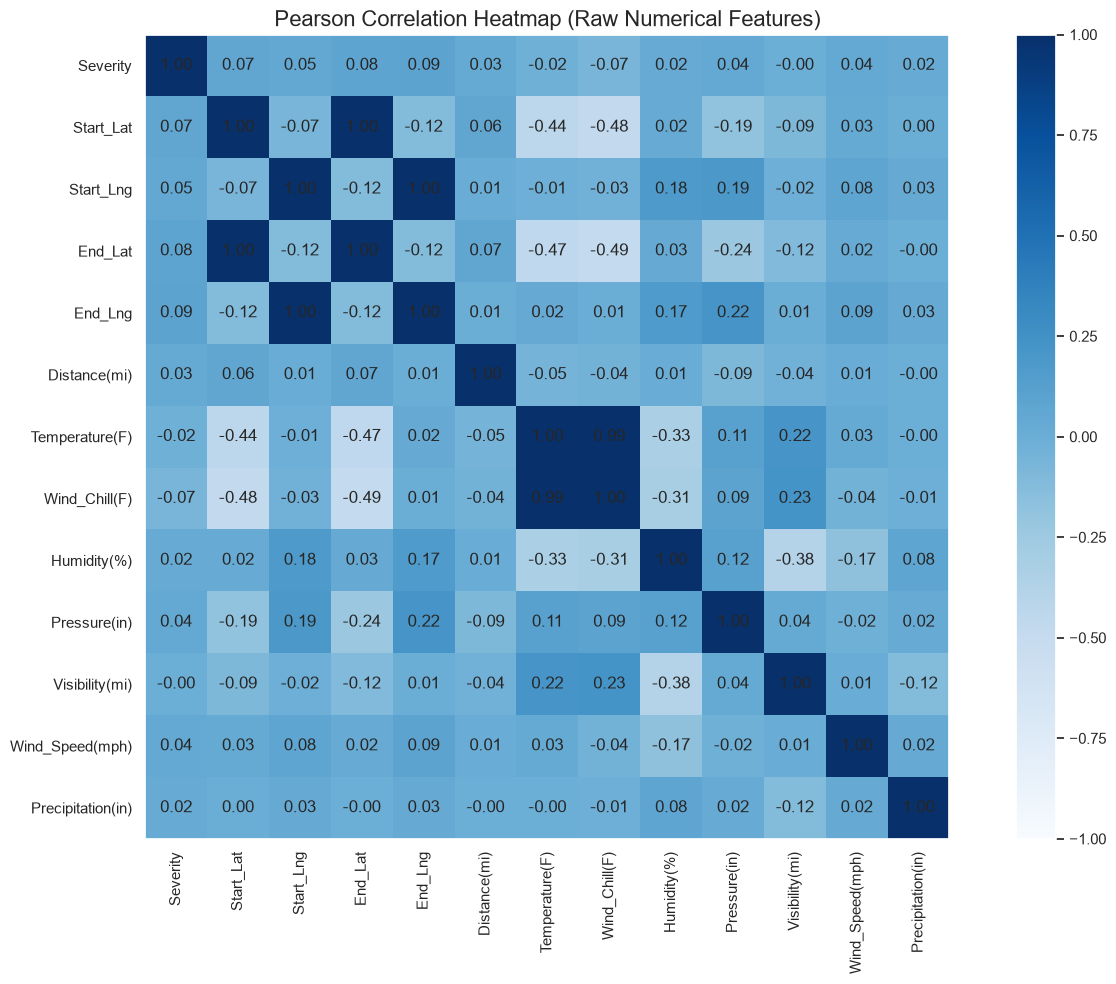

In [8]:
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
display(corr_matrix)

fig, ax = plt.subplots(figsize=(14, 10))

ax.grid(False)
cax = ax.imshow(corr_matrix, cmap='Blues', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

ax.set_title('Pearson Correlation Heatmap (Raw Numerical Features)', fontsize=16)
plt.tight_layout()
plt.show()

## 1.4 Severity classes

The classes are very unbalanced: most accidents are Severity 2.

In [9]:
severity_counts = df['Severity'].value_counts().sort_index()
severity_proportions = df['Severity'].value_counts(normalize=True).sort_index() * 100
severity_summary = pd.DataFrame({
    'Absolute_Count': severity_counts,
    'Percentage_(%)': severity_proportions
})
print("--- Accident Severity Distribution ---")
display(severity_summary.round(2))

--- Accident Severity Distribution ---


,Absolute_Count,Percentage_(%)
Severity,,
1,67366,0.87
2,6156981,79.67
3,1299337,16.81
4,204710,2.65


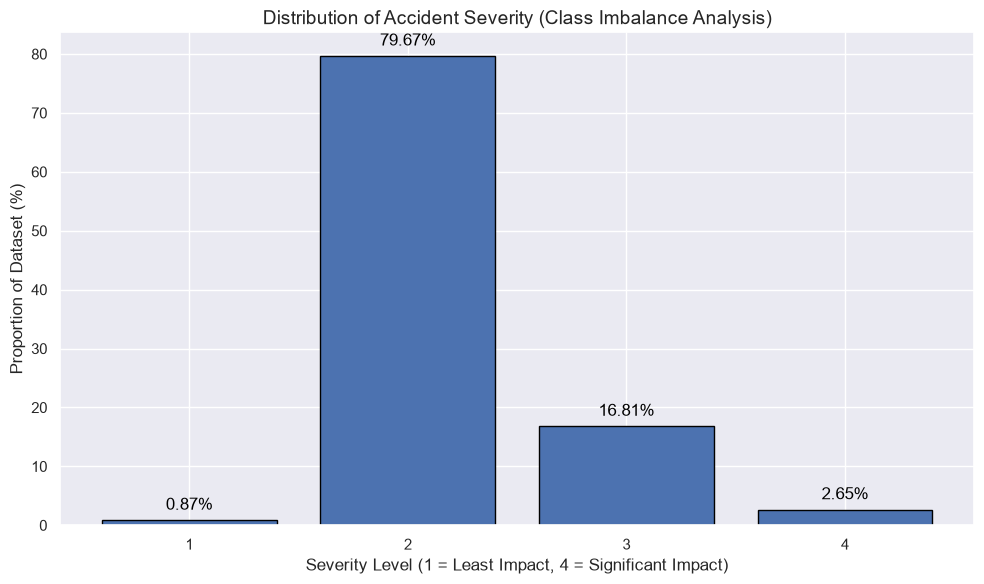

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    x=severity_summary.index.astype(str),
    height=severity_summary['Percentage_(%)'],
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f}%', 
        (bar.get_x() + bar.get_width() / 2., height), 
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='black', 
        xytext=(0, 5), 
        textcoords='offset points'
    )

ax.set_title('Distribution of Accident Severity (Class Imbalance Analysis)', fontsize=14)
ax.set_xlabel('Severity Level (1 = Least Impact, 4 = Significant Impact)', fontsize=12)
ax.set_ylabel('Proportion of Dataset (%)', fontsize=12)

plt.tight_layout()
plt.show()

## 1.5 Time patterns

`Start_Time` is stored in two formats: most rows look like `2016-02-08 05:46:00`, but some also carry fractional seconds. The cell below counts them.

In [11]:
if not pd.api.types.is_datetime64_any_dtype(df['Start_Time']):
    has_fraction = df['Start_Time'].str.contains('.', regex=False)
    print(f"Timestamps with fractional seconds: {has_fraction.sum():,} ({has_fraction.mean():.1%} of rows)")
    display(df.loc[[has_fraction.idxmin(), has_fraction.idxmax()], ['ID', 'Start_Time']])

Timestamps with fractional seconds: 743,166 (9.6% of rows)


,ID,Start_Time
0,A-1,2016-02-08 05:46:00
3639775,A-3649658,2017-07-23 04:21:01.000000000


In [12]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='ISO8601')
print("Timestamps that could not be parsed:", int(df['Start_Time'].isna().sum()))

df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek
df['Month'] = df['Start_Time'].dt.month

Timestamps that could not be parsed: 0


In [13]:
def get_normalized_distribution(df, time_col):
    counts = df.groupby([time_col, 'Severity']).size().unstack(fill_value=0)
    norm = counts.div(counts.sum(axis=0), axis=1) * 100
    return norm

In [14]:
norm_hour = get_normalized_distribution(df, 'Hour')
norm_day = get_normalized_distribution(df, 'DayOfWeek')
norm_month = get_normalized_distribution(df, 'Month')

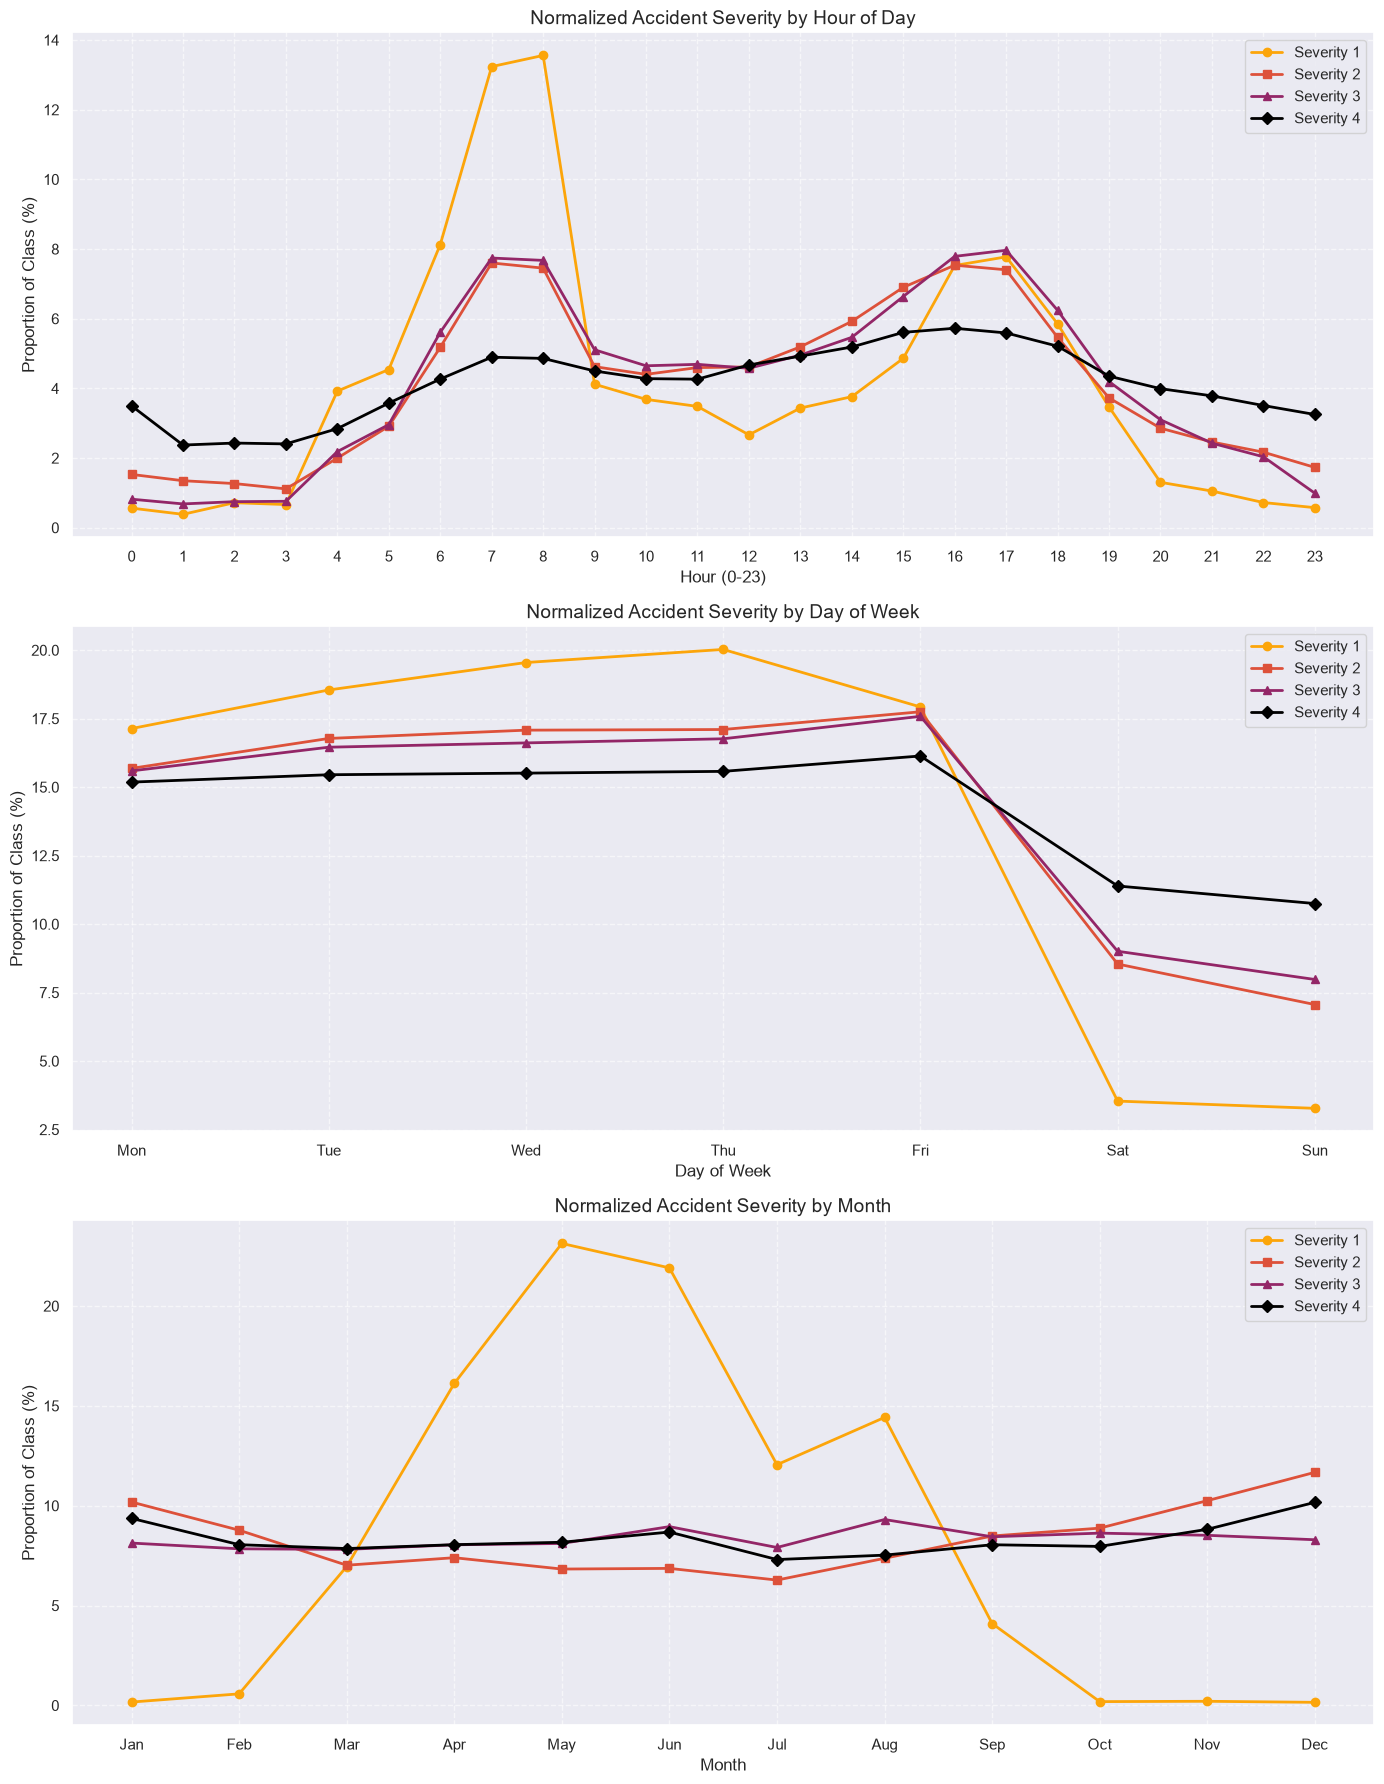

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
colors = ['#fca50a', '#dd513a', '#932667', '#000000']
markers = ['o', 's', '^', 'D']

for i, severity in enumerate([1, 2, 3, 4]):
    axes[0].plot(norm_hour.index, norm_hour[severity], color=colors[i], marker=markers[i], linewidth=2, label=f'Severity {severity}')
axes[0].set_title('Normalized Accident Severity by Hour of Day', fontsize=14)
axes[0].set_xlabel('Hour (0-23)', fontsize=12)
axes[0].set_ylabel('Proportion of Class (%)', fontsize=12)
axes[0].set_xticks(norm_hour.index)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for i, severity in enumerate([1, 2, 3, 4]):
    axes[1].plot(norm_day.index, norm_day[severity], color=colors[i], marker=markers[i], linewidth=2, label=f'Severity {severity}')
axes[1].set_title('Normalized Accident Severity by Day of Week', fontsize=14)
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Proportion of Class (%)', fontsize=12)
axes[1].set_xticks(norm_day.index)
axes[1].set_xticklabels(days)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i, severity in enumerate([1, 2, 3, 4]):
    axes[2].plot(norm_month.index, norm_month[severity], color=colors[i], marker=markers[i], linewidth=2, label=f'Severity {severity}')
axes[2].set_title('Normalized Accident Severity by Month', fontsize=14)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Proportion of Class (%)', fontsize=12)
axes[2].set_xticks(norm_month.index)
axes[2].set_xticklabels(months)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

# 2. Preparing the Data

## 2.1 Remove columns that cannot help

- `End_Lat`, `End_Lng` and `Wind_Chill(F)` repeat information already in other columns.
- `End_Time` and `Distance(mi)` are only known after the accident, so using them would leak the answer.
- Columns where one value covers more than 99% of rows carry almost no information.

In [16]:
redundant_cols = ['End_Lat', 'End_Lng', 'Wind_Chill(F)']
df_reduced = df.drop(columns=[col for col in redundant_cols if col in df.columns])
leakage_cols = ['End_Time', 'Distance(mi)']
df_reduced = df_reduced.drop(columns=[col for col in leakage_cols if col in df_reduced.columns])

In [17]:
print("Near-Zero Variance Check")
nzv_columns = []
threshold = 0.99

for col in df_reduced.columns:
    # Calculate the frequency of the most common value
    most_frequent_ratio = df_reduced[col].value_counts(normalize=True, dropna=False).iloc[0]
    if most_frequent_ratio > threshold:
        nzv_columns.append(col)
        print(f"Flagged {col}: Dominated by a single value ({most_frequent_ratio*100:.2f}%)")

df_reduced = df_reduced.drop(columns=nzv_columns)

print(f"\nOriginal feature count: {df.shape[1]}")
print(f"Reduced feature count: {df_reduced.shape[1]}")
print(f"Features removed: {len(df.columns) - len(df_reduced.columns)}")

Near-Zero Variance Check
Flagged Country: Dominated by a single value (100.00%)
Flagged Bump: Dominated by a single value (99.95%)
Flagged Give_Way: Dominated by a single value (99.53%)
Flagged No_Exit: Dominated by a single value (99.75%)
Flagged Railway: Dominated by a single value (99.13%)
Flagged Roundabout: Dominated by a single value (100.00%)
Flagged Traffic_Calming: Dominated by a single value (99.90%)
Flagged Turning_Loop: Dominated by a single value (100.00%)

Original feature count: 49
Reduced feature count: 36
Features removed: 13


## 2.2 Find accident hotspots

Two clustering methods are run on a sample of 100,000 accident locations. K-Means splits the map into 12 regions. HDBSCAN finds dense urban hotspots and marks everything else as noise.

In [18]:
from sklearn.cluster import KMeans, HDBSCAN
df_spatial = df_reduced.dropna(subset=['Start_Lat', 'Start_Lng']).copy()
if len(df_spatial) > 100000:
    df_sample = df_spatial.sample(n=100000, random_state=42).copy()
else:
    df_sample = df_spatial.copy()
coords = df_sample[['Start_Lng', 'Start_Lat']].values

In [19]:
kmeans = KMeans(n_clusters=12, random_state=42)
df_sample['KMeans_Cluster'] = kmeans.fit_predict(coords)

hdbscan_model = HDBSCAN(min_cluster_size=500, min_samples=50, metric='euclidean', copy=True)
df_sample['HDBSCAN_Cluster'] = hdbscan_model.fit_predict(coords)

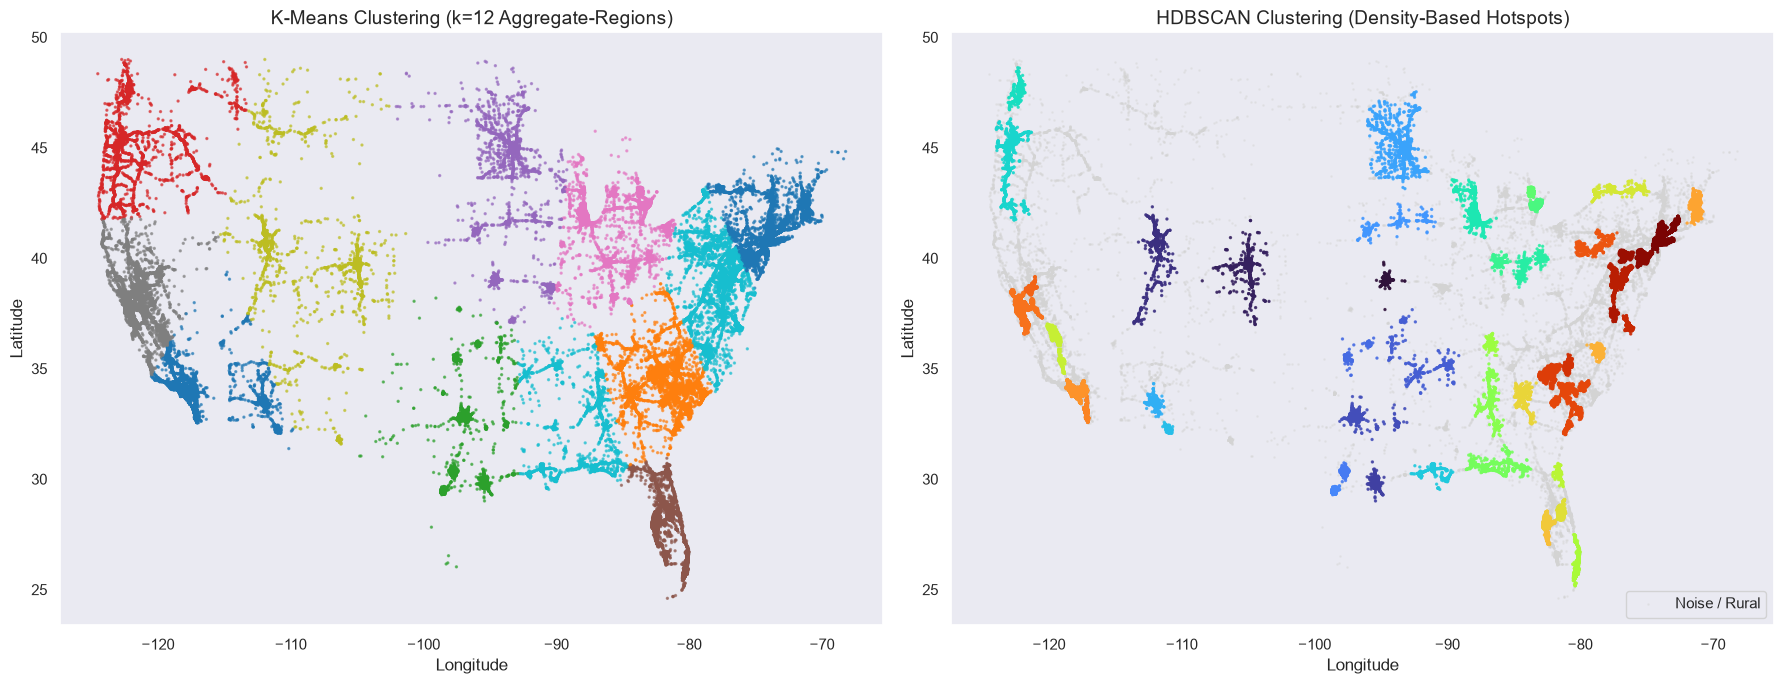

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(
    df_sample['Start_Lng'], 
    df_sample['Start_Lat'], 
    c=df_sample['KMeans_Cluster'], 
    cmap='tab10', 
    s=2, 
    alpha=0.6
)
axes[0].set_title('K-Means Clustering (k=12 Aggregate-Regions)', fontsize=14)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(False)

noise = df_sample[df_sample['HDBSCAN_Cluster'] == -1]
clusters = df_sample[df_sample['HDBSCAN_Cluster'] != -1]

axes[1].scatter(
    noise['Start_Lng'], 
    noise['Start_Lat'], 
    color='lightgrey', 
    s=1, 
    alpha=0.3, 
    label='Noise / Rural'
)

axes[1].scatter(
    clusters['Start_Lng'], 
    clusters['Start_Lat'], 
    c=clusters['HDBSCAN_Cluster'], 
    cmap='turbo', 
    s=2, 
    alpha=0.8
)

axes[1].set_title('HDBSCAN Clustering (Density-Based Hotspots)', fontsize=14)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(False)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [21]:
num_clusters = df_sample['HDBSCAN_Cluster'].nunique() - 1  # Exclude noise (-1)
noise_ratio = (len(noise) / len(df_sample)) * 100

print("Clustering Summary\n")
print("K-Means: Separated the data into 12 boundaries.")
print(f"HDBSCAN: Identified {num_clusters} high-density urban hotspots.")
print(f"HDBSCAN: Classified {noise_ratio:.2f}% of accidents as sparse/noise (-1).")

Clustering Summary

K-Means: Separated the data into 12 boundaries.
HDBSCAN: Identified 48 high-density urban hotspots.
HDBSCAN: Classified 18.16% of accidents as sparse/noise (-1).


## 2.3 Turn hotspots into a location feature

Each accident is assigned to the hotspot of its nearest sampled neighbours. Accidents outside every hotspot are labelled `Rural_Highway`.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
df_reduced = df_reduced.dropna(subset=['Start_Lat', 'Start_Lng']).copy()

In [23]:
zone_X = df_sample[['Start_Lng', 'Start_Lat']]
zone_y = df_sample['HDBSCAN_Cluster']
knn_spatial_proxy = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
knn_spatial_proxy.fit(zone_X, zone_y)
X_all = df_reduced[['Start_Lng', 'Start_Lat']]
df_reduced['HDBSCAN_Cluster'] = knn_spatial_proxy.predict(X_all)

In [24]:
def map_cluster_labels(cluster_id):
    if cluster_id == -1:
        return 'Rural_Highway'
    else:
        return f'Urban_Zone_{cluster_id}'

In [25]:
df_reduced['Spatial_Zone'] = df_reduced['HDBSCAN_Cluster'].apply(map_cluster_labels)
df_reduced['Spatial_Zone'] = df_reduced['Spatial_Zone'].astype('category')
cols_to_drop = ['Start_Lat', 'Start_Lng', 'HDBSCAN_Cluster']
if 'KMeans_Cluster' in df_reduced.columns:
    cols_to_drop.append('KMeans_Cluster')

df_final = df_reduced.drop(columns=cols_to_drop)

In [26]:
print(f"Original columns removed: {cols_to_drop}")
print("\nTop 10 Spatial Zones by Volume:")
print(df_final['Spatial_Zone'].value_counts().head(10))

Original columns removed: ['Start_Lat', 'Start_Lng', 'HDBSCAN_Cluster']

Top 10 Spatial Zones by Volume:
Spatial_Zone
Rural_Highway    1326956
Urban_Zone_34     769758
Urban_Zone_36     386764
Urban_Zone_47     368050
Urban_Zone_24     343202
Urban_Zone_43     241952
Urban_Zone_4      230309
Urban_Zone_16     190159
Urban_Zone_3      189568
Urban_Zone_10     184912
Name: count, dtype: int64


## 2.5 Convert columns to numbers and categories

True/False columns become 1/0, the four day/night columns become 0 (day) and 1 (night), and the remaining text columns become categories.

In [28]:
bool_columns = df_final.select_dtypes(include=['bool']).columns
df_final[bool_columns] = df_final[bool_columns].astype(int)

In [29]:
for col in ['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']:
    if col in df_final.columns:
        df_final[col] = df_final[col].map({'Day': 0, 'Night': 1})

In [30]:
object_columns = df_final.select_dtypes(include=['object', 'str']).columns
df_final[object_columns] = df_final[object_columns].astype('category')

In [31]:
print(f"Final Dataset Memory Usage: {df_final.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"Final Feature Count: {df_final.shape[1]}")

display(df_final.head())

Final Dataset Memory Usage: 1608.77 MB
Final Feature Count: 34


,ID,Source,Severity,Start_Time,Street,City,County,State,Zipcode,Timezone,...,Stop,Traffic_Signal,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,DayOfWeek,Month,Spatial_Zone
0,A-1,Source2,3,2016-02-08 05:46:00,I-70 E,Dayton,Montgomery,OH,45424,US/Eastern,...,0,0,1.0,1.0,1.0,1.0,5,0,2,Urban_Zone_17
1,A-2,Source2,2,2016-02-08 06:07:59,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US/Eastern,...,0,0,1.0,1.0,1.0,0.0,6,0,2,Urban_Zone_17
2,A-3,Source2,2,2016-02-08 06:49:27,State Route 32,Williamsburg,Clermont,OH,45176,US/Eastern,...,0,1,1.0,1.0,0.0,0.0,6,0,2,Urban_Zone_17
3,A-4,Source2,3,2016-02-08 07:23:34,I-75 S,Dayton,Montgomery,OH,45417,US/Eastern,...,0,0,1.0,0.0,0.0,0.0,7,0,2,Urban_Zone_17
4,A-5,Source2,2,2016-02-08 07:39:07,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US/Eastern,...,0,1,0.0,0.0,0.0,0.0,7,0,2,Urban_Zone_17


# 3. Train, Validation and Test Split

70% of the rows are used for training, 15% for validation and 15% for testing. Each part keeps the same share of every severity class.

`ID` and `Weather_Timestamp` are removed here: one is a row identifier and the other a raw timestamp string, so neither can help a model, and one-hot encoding them would create millions of columns.

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
columns_to_drop = ['Severity']
for col in ['Start_Time', 'ID', 'Weather_Timestamp']:
    if col in df_final.columns:
        columns_to_drop.append(col)
print("Columns not used as features:", columns_to_drop)

Columns not used as features: ['Severity', 'Start_Time', 'ID', 'Weather_Timestamp']


In [34]:
X = df_final.drop(columns=columns_to_drop)
y = df_final['Severity']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y  
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

In [35]:
def check_distribution(series, name):
    dist = series.value_counts(normalize=True).sort_index() * 100
    print(f"{name} Distribution (%):\n{dist.round(2)}\n")

In [36]:
print("Split Verification\n")
print(f"Training Set:   {X_train.shape[0]} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation Set: {X_val.shape[0]} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test Set:       {X_test.shape[0]} rows ({len(X_test)/len(X)*100:.0f}%)\n")

check_distribution(y, "Global Target")
check_distribution(y_train, "Training Set Target")
check_distribution(y_test, "Test Set Target")

Split Verification

Training Set:   5409875 rows (70%)
Validation Set: 1159259 rows (15%)
Test Set:       1159260 rows (15%)

Global Target Distribution (%):
Severity
1     0.87
2    79.67
3    16.81
4     2.65
Name: proportion, dtype: float64

Training Set Target Distribution (%):
Severity
1     0.87
2    79.67
3    16.81
4     2.65
Name: proportion, dtype: float64

Test Set Target Distribution (%):
Severity
1     0.87
2    79.67
3    16.81
4     2.65
Name: proportion, dtype: float64



In [37]:
import gc

# Free memory: these tables are not needed again (df is kept for the feature engineering in section 9)
for name in ["df_spatial", "df_reduced", "df_final", "X", "X_temp", "X_all"]:
    globals().pop(name, None)
gc.collect();

# 4. Class Weights

Rare classes get a larger weight so the models do not ignore them.

In [38]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.sort(np.unique(y_train))
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
for cls, weight in class_weights_dict.items():
    print(f"Severity {cls}: {weight:.4f}")

Severity 1: 28.6807
Severity 2: 0.3138
Severity 3: 1.4870
Severity 4: 9.4382


# 5. Scoring Helpers

Every model is scored the same way:

- **Macro F1:** the average F1 score over the four classes, so rare classes count as much as common ones.
- **Balanced accuracy:** the average recall over the four classes.

`evaluate` prints the scores and stores them for the final comparison. `plot_results` draws the confusion matrix and the per-class scores.

In [39]:
import time
from sklearn.metrics import (accuracy_score, classification_report, balanced_accuracy_score, f1_score,
                             confusion_matrix, precision_recall_fscore_support)

results = {}

def evaluate(name, y_true, y_pred, report=True):
    f1 = f1_score(y_true, y_pred, average=None, labels=classes, zero_division=0)
    results[name] = dict(test_rows=len(y_true),
                         accuracy=accuracy_score(y_true, y_pred),
                         macro_f1=f1.mean(),
                         balanced_accuracy=balanced_accuracy_score(y_true, y_pred),
                         **{f"f1_sev{c}": v for c, v in zip(classes, f1)})
    if report:
        print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print(f"{name}: macro F1 {results[name]['macro_f1']:.4f}, "
          f"balanced accuracy {results[name]['balanced_accuracy']:.4f}")

def plot_results(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=classes, zero_division=0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    cax = axes[0].imshow(cm_pct, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
    fig.colorbar(cax, ax=axes[0], fraction=0.046, pad=0.04, label="% of true class")
    axes[0].set_xticks(np.arange(len(classes))); axes[0].set_yticks(np.arange(len(classes)))
    axes[0].set_xticklabels(classes); axes[0].set_yticklabels(classes)
    axes[0].set_xlabel("Predicted Severity", fontsize=12); axes[0].set_ylabel("True (Actual) Severity", fontsize=12)
    axes[0].set_title(f"{title}: Confusion Matrix", fontsize=14)
    for i in range(len(classes)):
        for j in range(len(classes)):
            axes[0].text(j, i, f"{cm[i, j]:,}\n{cm_pct[i, j]:.1f}%", ha="center", va="center",
                         color="white" if cm_pct[i, j] > 50 else "black")
    axes[0].grid(False)

    x = np.arange(len(classes)); width = 0.25
    axes[1].bar(x - width, precision, width, label="Precision", color="#4c72b0", edgecolor="black")
    axes[1].bar(x, recall, width, label="Recall", color="#dd513a", edgecolor="black")
    axes[1].bar(x + width, f1, width, label="F1-Score", color="#55a868", edgecolor="black")
    axes[1].set_xlabel("Severity Class", fontsize=12); axes[1].set_ylabel("Score (0.0 to 1.0)", fontsize=12)
    axes[1].set_title(f"{title}: Scores by Class", fontsize=14)
    axes[1].set_xticks(x); axes[1].set_xticklabels(classes); axes[1].set_ylim(0, 1.1)
    axes[1].legend(loc="upper right"); axes[1].grid(axis="y", linestyle="--", alpha=0.6)

    plt.tight_layout(); plt.show()

# 6. Model 1: K-Nearest Neighbours

KNN compares every test row with every training row, which is far too slow on 5 million rows. It is trained on a 100,000-row sample and tested on a 10,000-row sample, both keeping the class proportions.

Numeric columns are filled with the median and scaled. Category columns are one-hot encoded, with rare values (under 0.1% of rows) grouped together.

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

def make_preprocessor(X, min_frequency=0.001):
    categorical_cols = X.select_dtypes(include=['category']).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=['category']).columns.tolist()
    return ColumnTransformer(transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=min_frequency,
                                     sparse_output=True)),
        ]), categorical_cols),
    ])

In [41]:
sample_train_size = 100000
sample_test_size = 10000

In [42]:
X_train_sub = X_train.groupby(y_train, group_keys=False).apply(
    lambda x: x.sample(int(sample_train_size * len(x) / len(X_train)), random_state=42)
)
y_train_sub = y_train.loc[X_train_sub.index]

X_test_sub = X_test.groupby(y_test, group_keys=False).apply(
    lambda x: x.sample(int(sample_test_size * len(x) / len(X_test)), random_state=42)
)
y_test_sub = y_test.loc[X_test_sub.index]

In [43]:
preprocessor_knn = make_preprocessor(X_train_sub)
X_train_knn_sub = preprocessor_knn.fit_transform(X_train_sub)
X_test_knn_sub = preprocessor_knn.transform(X_test_sub)
print("Training rows:", X_train_knn_sub.shape[0], "| columns after encoding:", X_train_knn_sub.shape[1])

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_knn_sub, y_train_sub)
y_pred_knn_sub = knn_model.predict(X_test_knn_sub)

Training rows: 99998 | columns after encoding: 860


              precision    recall  f1-score   support

           1     0.3333    0.0690    0.1143        87
           2     0.8443    0.9588    0.8979      7966
           3     0.6527    0.3510    0.4565      1681
           4     0.2759    0.0303    0.0546       264

    accuracy                         0.8244      9998
   macro avg     0.5265    0.3523    0.3808      9998
weighted avg     0.7926    0.8244    0.7946      9998

KNN (100k-row sample): macro F1 0.3808, balanced accuracy 0.3523


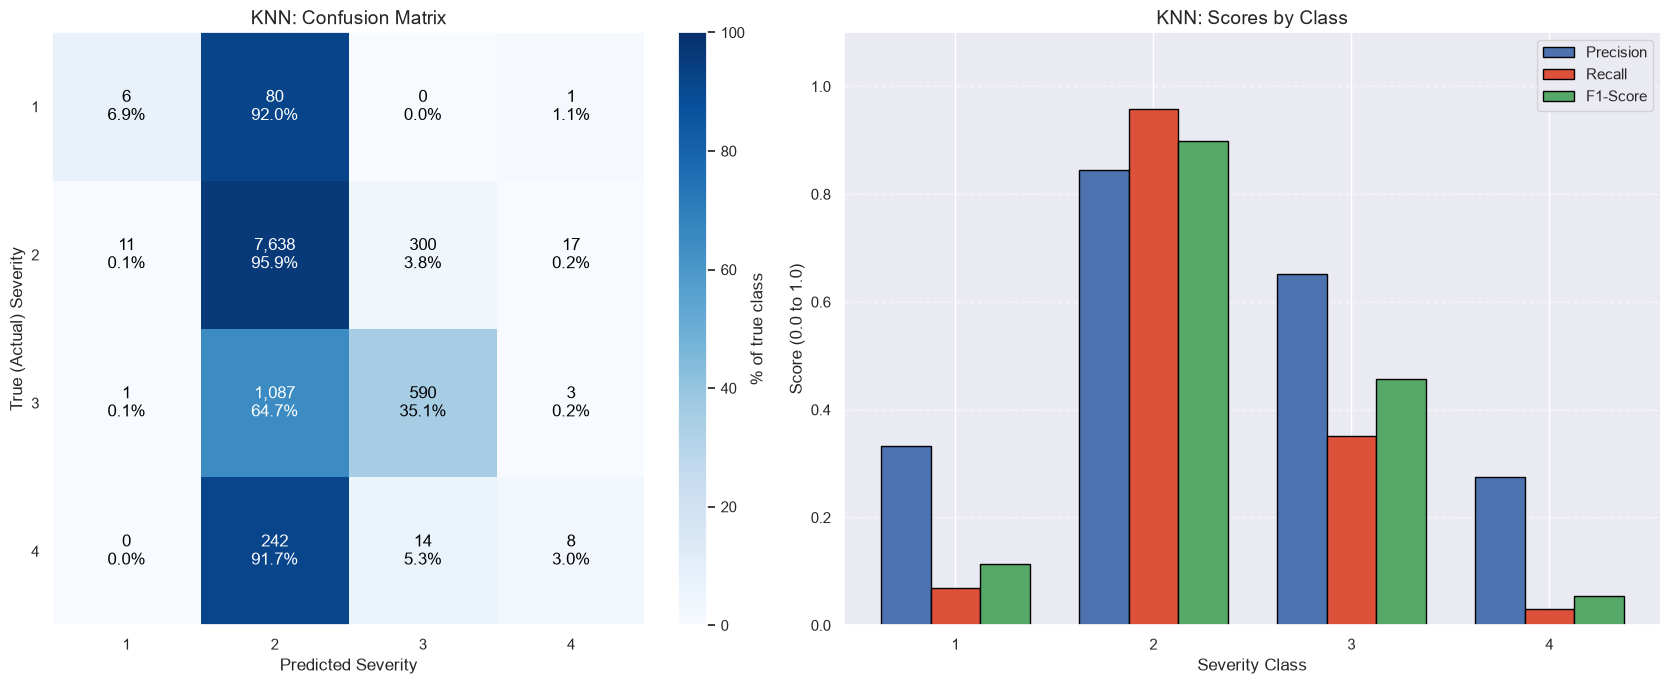

In [44]:
evaluate("KNN (100k-row sample)", y_test_sub, y_pred_knn_sub)
plot_results(y_test_sub, y_pred_knn_sub, "KNN")

# 7. Model 2: Logistic Regression

Trained on a 1-million-row sample of the training set with the class weights from section 4, and tested on the full test set.

In [45]:
from sklearn.linear_model import LogisticRegression

LR_SAMPLE = 1_000_000
lr_idx = X_train.sample(n=min(LR_SAMPLE, len(X_train)), random_state=42).index

print("Transforming data...")
start_time = time.time()
preprocessor_lr = make_preprocessor(X_train)
X_train_lr = preprocessor_lr.fit_transform(X_train.loc[lr_idx])
X_test_lr = preprocessor_lr.transform(X_test)
y_train_lr = y_train.loc[lr_idx]
print(f"Transformation complete in {time.time() - start_time:.0f} seconds")
print("Training rows:", X_train_lr.shape[0], "| columns after encoding:", X_train_lr.shape[1])

Transforming data...
Transformation complete in 14 seconds
Training rows: 1000000 | columns after encoding: 855


In [46]:
log_reg = LogisticRegression(solver="saga", class_weight=class_weights_dict, max_iter=300, tol=1e-3, random_state=42)

print("Training logistic regression...")
start_time = time.time()
log_reg.fit(X_train_lr, y_train_lr)
print(f"Training complete in {time.time() - start_time:.0f} seconds, iterations used: {int(log_reg.n_iter_.max())}")

Training logistic regression...
Training complete in 257 seconds, iterations used: 300


c:\Data Science\US Accidents\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           1     0.0441    0.7974    0.0836     10105
           2     0.9555    0.4776    0.6369    923548
           3     0.5083    0.7776    0.6148    194901
           4     0.1040    0.7339    0.1822     30706

    accuracy                         0.5376   1159260
   macro avg     0.4030    0.6966    0.3793   1159260
weighted avg     0.8498    0.5376    0.6163   1159260

Logistic regression: macro F1 0.3793, balanced accuracy 0.6966


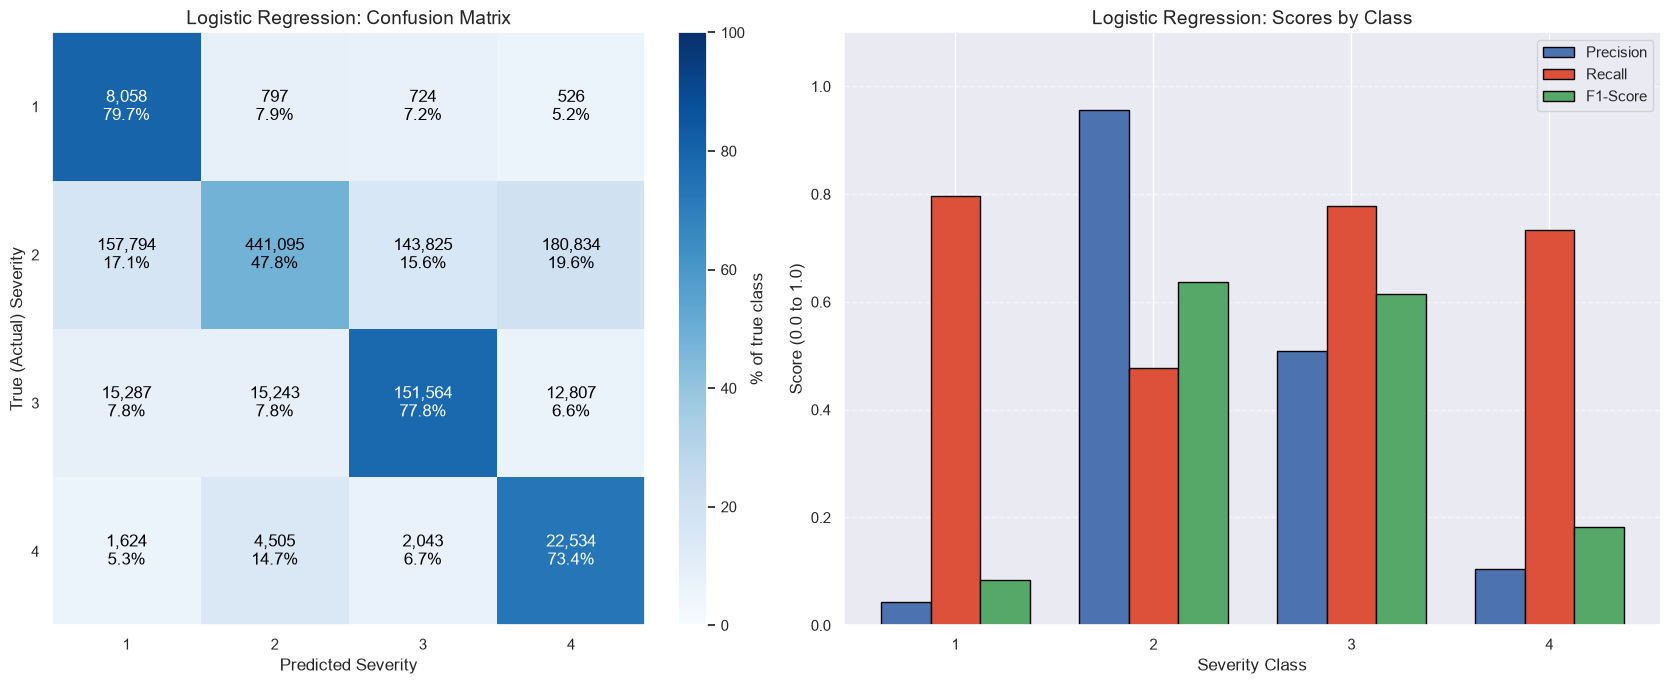

In [47]:
y_pred_lr = log_reg.predict(X_test_lr)
evaluate("Logistic regression", y_test, y_pred_lr)
plot_results(y_test, y_pred_lr, "Logistic Regression")

# 8. Model 3: XGBoost

## 8.1 Prepare the features

XGBoost reads category columns directly, so no one-hot encoding is needed. Columns with thousands of values (street, city, ZIP code) are limited to their 253 most frequent values, with the rest grouped as "Other".

In [48]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

MAX_CATEGORIES = 254

Xtr, Xva, Xte = X_train.copy(), X_val.copy(), X_test.copy()
splits = (Xtr, Xva, Xte)

xgb_cat_cols = Xtr.select_dtypes(include=["category"]).columns.tolist()
for col in xgb_cat_cols:
    same_dtype = all(d[col].dtype == Xtr[col].dtype for d in splits)
    if same_dtype and len(Xtr[col].cat.categories) <= MAX_CATEGORIES:
        continue                                 # few enough values already
    top = Xtr[col].value_counts().head(MAX_CATEGORIES - 1).index.astype(str).tolist()
    dtype = pd.CategoricalDtype(top if "Other" in top else top + ["Other"])
    for d in splits:
        s = d[col].astype("object")
        d[col] = s.where(s.isin(top) | s.isna(), "Other").astype(dtype)

FEATURES_BASE = Xtr.columns.tolist()
print("Features:", len(FEATURES_BASE))
print("Categorical:", {c: len(Xtr[c].cat.categories) for c in xgb_cat_cols})

XGBoost version: 3.4.1
Features: 30
Categorical: {'Source': 3, 'Street': 254, 'City': 254, 'County': 254, 'State': 49, 'Zipcode': 254, 'Timezone': 4, 'Airport_Code': 254, 'Wind_Direction': 24, 'Weather_Condition': 144, 'Spatial_Zone': 49}


XGBoost needs class labels that start at 0, so severity 1 to 4 is mapped to 0 to 3 for training and mapped back for the results. The class weights are the square root of the balanced weights, which is a milder correction than the one used for logistic regression.

In [49]:
to_xgb = {c: i for i, c in enumerate(classes)}            # severity 1..4 -> label 0..3
y_train_xgb, y_val_xgb = y_train.map(to_xgb), y_val.map(to_xgb)

xgb_class_weight = dict(zip(classes, np.sqrt(weights)))
w_train = y_train.map(xgb_class_weight).to_numpy()
w_val = y_val.map(xgb_class_weight).to_numpy()
print({int(k): round(float(v), 3) for k, v in xgb_class_weight.items()})

{1: 5.355, 2: 0.56, 3: 1.219, 4: 3.072}


## 8.2 Train the baseline model

Training stops automatically when the validation loss has not improved for 50 rounds. The same settings and the same helper function are used for every XGBoost model in this notebook, so the models differ only in their features.

In [50]:
BASE_PARAMS = dict(
    objective="multi:softprob",
    tree_method="hist",
    device="cuda",                 # uses the GPU; falls back to CPU with a warning if none is found
    enable_categorical=True,
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    max_bin=256,
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

def fit_xgb(features, params=None, verbose=100):
    model = xgb.XGBClassifier(**{**BASE_PARAMS, **(params or {})})
    t0 = time.time()
    model.fit(Xtr[features], y_train_xgb, sample_weight=w_train,
              eval_set=[(Xva[features], y_val_xgb)], sample_weight_eval_set=[w_val], verbose=verbose)
    print(f"Training time: {time.time() - t0:.0f} s | best iteration: {model.best_iteration} | "
          f"validation mlogloss: {model.best_score:.4f}")
    model.set_params(device="cpu")                          # predict on CPU, where the data lives
    return model, model.predict_proba(Xva[features]), model.predict_proba(Xte[features])

def plot_importance(model, title, top=20):
    importance = pd.Series(model.get_booster().get_score(importance_type="gain")).sort_values()
    importance.tail(top).plot.barh(figsize=(10, 0.32 * top + 1), color="#4c72b0", edgecolor="black")
    plt.xlabel("Average gain per split"); plt.title(title)
    plt.tight_layout(); plt.show()

In [51]:
model_base, proba_val_base, proba_test_base = fit_xgb(FEATURES_BASE)
y_pred_xgb = classes[proba_test_base.argmax(axis=1)]       # back to severity 1..4

[0]	validation_0-mlogloss:1.00416
[100]	validation_0-mlogloss:0.51068
[200]	validation_0-mlogloss:0.50083
[300]	validation_0-mlogloss:0.49818
[400]	validation_0-mlogloss:0.49733
[500]	validation_0-mlogloss:0.49725
[519]	validation_0-mlogloss:0.49725
Training time: 87 s | best iteration: 469 | validation mlogloss: 0.4971


## 8.3 Test results

              precision    recall  f1-score   support

           1     0.2567    0.6102    0.3614     10105
           2     0.9412    0.8837    0.9115    923548
           3     0.7045    0.7952    0.7471    194901
           4     0.3091    0.4841    0.3773     30706

    accuracy                         0.8559   1159260
   macro avg     0.5529    0.6933    0.5993   1159260
weighted avg     0.8787    0.8559    0.8649   1159260

XGBoost baseline: macro F1 0.5993, balanced accuracy 0.6933


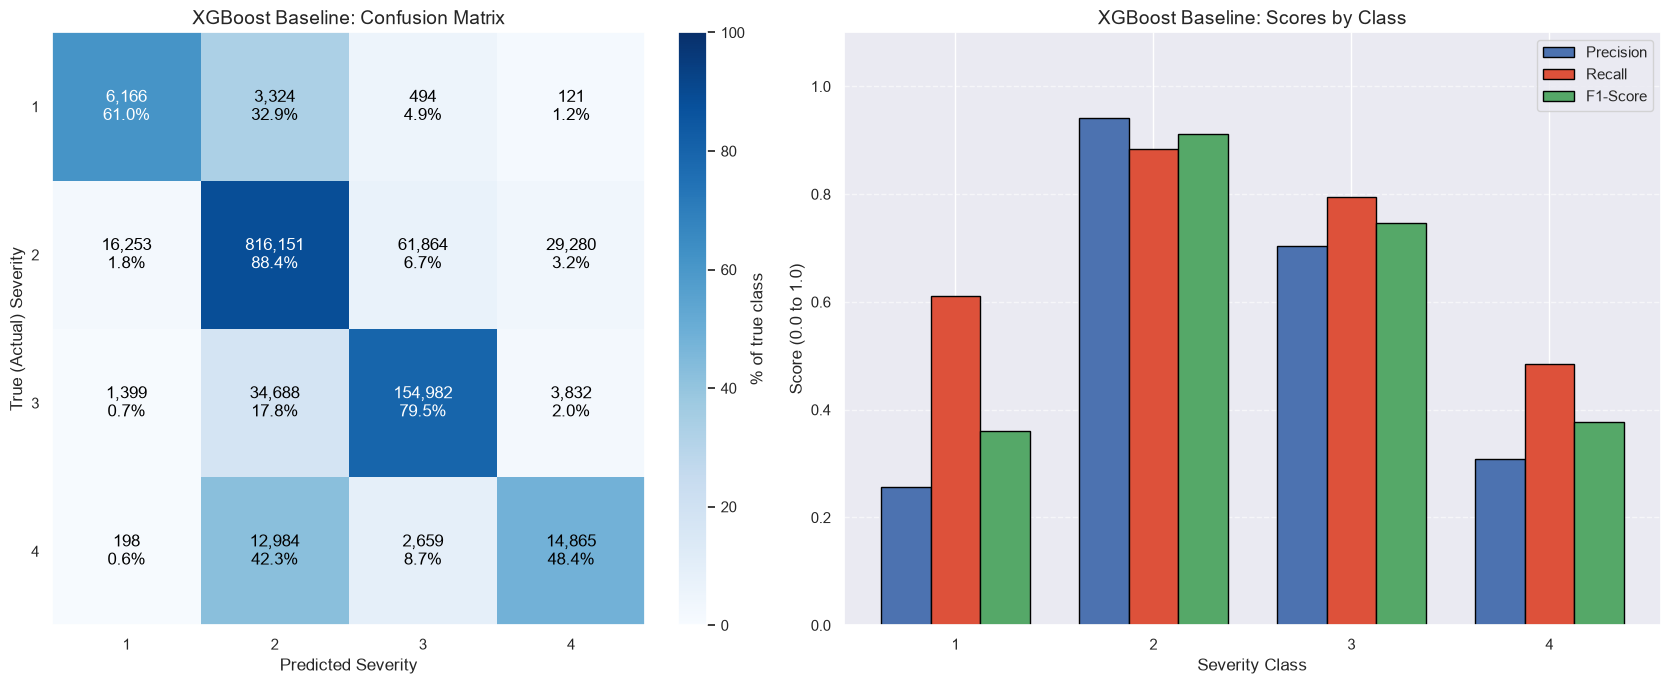

In [52]:
evaluate("XGBoost baseline", y_test, y_pred_xgb)
plot_results(y_test, y_pred_xgb, "XGBoost Baseline")

## 8.4 Which features matter most

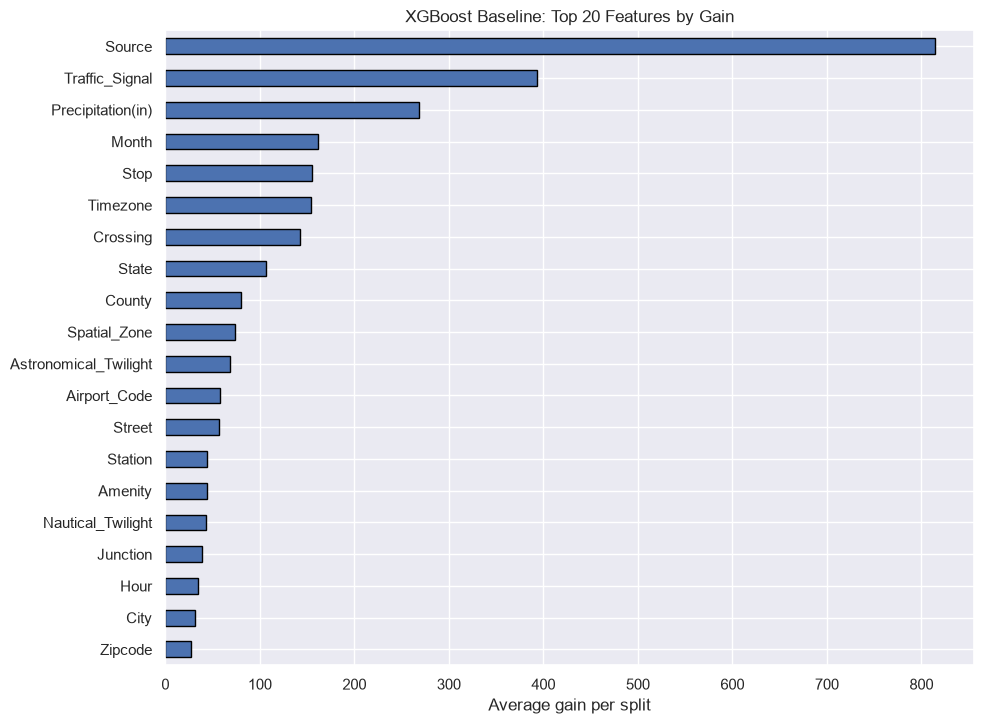

In [53]:
plot_importance(model_base, "XGBoost Baseline: Top 20 Features by Gain")

# 9. Improving XGBoost

The baseline stops improving after a few hundred rounds, so more trees will not help. The steps below improve what the model is given and how its predictions are chosen:

1. Add new features.
2. Encode locations by their severity history.
3. Check whether `Year` and `Source` inflate the score.
4. Tune the decision rule.
5. Search for better settings.
6. Train the final model.

## 9.1 Add new features

- **Start_Lat, Start_Lng:** the exact location, alongside the hotspot zones.
- **Year:** the year of the accident.
- **Is_Weekend:** 1 for Saturday and Sunday.
- **Is_Highway:** 1 if the street name looks like an interstate, highway, freeway, route or parkway.
- **Precip_Missing:** 1 if no precipitation value was recorded.

In [54]:
HIGHWAY = r"\bI-\d|INTERSTATE|\bHWY\b|HIGHWAY|FWY|FREEWAY|EXPY|EXPRESSWAY|TPKE|TURNPIKE|\bUS-\d|\bROUTE\b|\bRTE\b|PKWY|PARKWAY"

extra = pd.DataFrame({
    "Start_Lat": df["Start_Lat"].astype("float32"),
    "Start_Lng": df["Start_Lng"].astype("float32"),
    "Year": df["Start_Time"].dt.year.astype("int16"),
    "Is_Weekend": (df["DayOfWeek"] >= 5).astype("int8"),
    "Is_Highway": df["Street"].str.upper().str.contains(HIGHWAY, regex=True, na=False).astype("int8"),
    "Precip_Missing": df["Precipitation(in)"].isna().astype("int8"),
})
NEW_FEATURES = extra.columns.tolist()
print("Share of accidents:")
print(extra[["Is_Highway", "Is_Weekend", "Precip_Missing"]].mean().round(3))

def add_features(X):
    X = X.drop(columns=[c for c in NEW_FEATURES if c in X.columns])
    return X.join(extra.loc[X.index])

Xtr, Xva, Xte = add_features(Xtr), add_features(Xva), add_features(Xte)

FEATURES_V2 = FEATURES_BASE + NEW_FEATURES
print("\nBaseline features:", len(FEATURES_BASE), "-> with new features:", len(FEATURES_V2))

Share of accidents:
Is_Highway        0.455
Is_Weekend        0.159
Precip_Missing    0.285
dtype: float64

Baseline features: 30 -> with new features: 36


## 9.2 Train with the new features

In [55]:
model_v2, proba_val_v2, proba_test_v2 = fit_xgb(FEATURES_V2)
evaluate("XGBoost + new features", y_test, classes[proba_test_v2.argmax(axis=1)])

[0]	validation_0-mlogloss:0.97687
[100]	validation_0-mlogloss:0.41787
[200]	validation_0-mlogloss:0.40946
[300]	validation_0-mlogloss:0.40647
[400]	validation_0-mlogloss:0.40545
[500]	validation_0-mlogloss:0.40518
[570]	validation_0-mlogloss:0.40522
Training time: 104 s | best iteration: 520 | validation mlogloss: 0.4051
              precision    recall  f1-score   support

           1     0.4912    0.8760    0.6295     10105
           2     0.9560    0.9018    0.9281    923548
           3     0.7268    0.8292    0.7746    194901
           4     0.3406    0.5289    0.4144     30706

    accuracy                         0.8795   1159260
   macro avg     0.6287    0.7840    0.6866   1159260
weighted avg     0.8971    0.8795    0.8861   1159260

XGBoost + new features: macro F1 0.6866, balanced accuracy 0.7840


## 9.3 Encode locations by their severity history

The baseline keeps only the 253 most frequent streets, cities, counties, ZIP codes and airports. Target encoding replaces each value with the share of each severity class seen for it in the training data, so every value contributes.

To avoid a row's own label leaking into its encoding, the training set is encoded with 5-fold cross-fitting. Validation and test rows are encoded using training data only.

In [56]:
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import StratifiedKFold

# Integer codes for the location columns (missing = -1). ZIP codes are cut to their first 5 digits.
TE_COLS = ["Street", "City", "County", "Zip5", "Airport_Code"]
loc_source = df[["Street", "City", "County", "Airport_Code"]].assign(Zip5=df["Zipcode"].str[:5])
loc_codes = pd.DataFrame({c: loc_source[c].astype("category").cat.codes for c in TE_COLS})
print("Distinct values:", {c: int(loc_codes[c].max()) + 1 for c in TE_COLS})
del loc_source

t0 = time.time()
target_encoder = TargetEncoder(target_type="multiclass", smooth="auto",
                               cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
te_train = target_encoder.fit_transform(loc_codes.loc[Xtr.index], y_train)
TE_FEATURES = ["TE_" + n for n in target_encoder.get_feature_names_out()]

for frame, values in ((Xtr, te_train),
                      (Xva, target_encoder.transform(loc_codes.loc[Xva.index])),
                      (Xte, target_encoder.transform(loc_codes.loc[Xte.index]))):
    for j, name in enumerate(TE_FEATURES):
        frame[name] = values[:, j].astype("float32")
del te_train
gc.collect()

FEATURES_V3 = FEATURES_V2 + TE_FEATURES
print(f"Target encoding done in {time.time() - t0:.0f} s; added {len(TE_FEATURES)} features, "
      f"for example {TE_FEATURES[:4]}")

Distinct values: {'Street': 336306, 'City': 13678, 'County': 1871, 'Zip5': 24236, 'Airport_Code': 2045}
Target encoding done in 12 s; added 20 features, for example ['TE_Street_1', 'TE_Street_2', 'TE_Street_3', 'TE_Street_4']


In [57]:
model_v3, proba_val_v3, proba_test_v3 = fit_xgb(FEATURES_V3)
evaluate("XGBoost + location encoding", y_test, classes[proba_test_v3.argmax(axis=1)])

[0]	validation_0-mlogloss:0.96571
[100]	validation_0-mlogloss:0.37397
[200]	validation_0-mlogloss:0.36890
[300]	validation_0-mlogloss:0.36821
[367]	validation_0-mlogloss:0.36826
Training time: 93 s | best iteration: 317 | validation mlogloss: 0.3682
              precision    recall  f1-score   support

           1     0.4834    0.8909    0.6268     10105
           2     0.9649    0.9119    0.9377    923548
           3     0.7643    0.8684    0.8131    194901
           4     0.3591    0.5415    0.4318     30706

    accuracy                         0.8946   1159260
   macro avg     0.6429    0.8032    0.7023   1159260
weighted avg     0.9109    0.8946    0.9006   1159260

XGBoost + location encoding: macro F1 0.7023, balanced accuracy 0.8032


## 9.4 Check: do `Year` and `Source` inflate the score?

`Year` and `Source` say when an accident was recorded and which data provider recorded it. If providers or periods assigned severity differently, a model can score well by learning the recording process instead of the accident.

The two tables show the share of each severity class by year and by source. Large differences between rows are a warning sign.

In [58]:
by_year = pd.crosstab(df["Start_Time"].dt.year.rename("Year"), df["Severity"], normalize="index").mul(100).round(1)
by_source = pd.crosstab(df["Source"], df["Severity"], normalize="index").mul(100).round(1)
print("Severity mix by year (% of accidents in that year)")
display(by_year)
print("Severity mix by source (% of accidents from that source)")
display(by_source)

Severity mix by year (% of accidents in that year)


Severity,1,2,3,4
Year,,,,
2016,0.1,65.7,30.7,3.5
2017,0.0,64.4,32.2,3.4
2018,0.0,64.3,32.8,2.9
2019,0.0,72.1,24.9,2.9
2020,2.4,79.2,15.7,2.6
2021,0.0,88.5,9.5,2.0
2022,2.1,91.0,4.4,2.5
2023,0.0,97.1,0.0,2.9


Severity mix by source (% of accidents from that source)


Severity,1,2,3,4
Source,,,,
Source1,0.7,91.2,3.7,4.4
Source2,1.1,65.0,33.5,0.4
Source3,4.2,64.1,31.6,0.2


The model is now trained again without these two columns. The drop in score is the part that depends on how severity was recorded.

In [59]:
FEATURES_NO_YS = [c for c in FEATURES_V3 if c not in ("Year", "Source")]
model_no_ys, proba_val_no_ys, proba_test_no_ys = fit_xgb(FEATURES_NO_YS)
evaluate("XGBoost without Year and Source", y_test, classes[proba_test_no_ys.argmax(axis=1)])

with_ys = results["XGBoost + location encoding"]["macro_f1"]
without_ys = results["XGBoost without Year and Source"]["macro_f1"]
print(f"\nMacro F1 with Year and Source: {with_ys:.4f} | without: {without_ys:.4f} | difference: {with_ys - without_ys:+.4f}")

[0]	validation_0-mlogloss:1.01606
[100]	validation_0-mlogloss:0.59726
[200]	validation_0-mlogloss:0.58681
[300]	validation_0-mlogloss:0.58353
[400]	validation_0-mlogloss:0.58207
[500]	validation_0-mlogloss:0.58144
[598]	validation_0-mlogloss:0.58146
Training time: 140 s | best iteration: 548 | validation mlogloss: 0.5813
              precision    recall  f1-score   support

           1     0.2465    0.5510    0.3407     10105
           2     0.9272    0.8635    0.8942    923548
           3     0.6128    0.7410    0.6708    194901
           4     0.3163    0.4209    0.3612     30706

    accuracy                         0.8285   1159260
   macro avg     0.5257    0.6441    0.5667   1159260
weighted avg     0.8522    0.8285    0.8377   1159260

XGBoost without Year and Source: macro F1 0.5667, balanced accuracy 0.6441

Macro F1 with Year and Source: 0.7023 | without: 0.5667 | difference: +0.1356


## 9.5 Tune the decision rule

By default the model predicts the class with the highest probability. With classes this unbalanced, that is not the best rule for macro F1. One multiplier per class is chosen on the validation set (never the test set) and then applied to the test predictions.

The multipliers are tuned for macro F1 only. They shift the balance between precision and recall for the rare classes, so balanced accuracy can move in either direction. Compare both scores before and after.

In [60]:
def tune_scale(proba_val, n_sub=300_000, seed=42):
    y_idx = y_val_xgb.to_numpy()
    sub = np.random.default_rng(seed).choice(len(y_idx), min(n_sub, len(y_idx)), replace=False)
    score = lambda s: f1_score(y_idx[sub], (proba_val[sub] * s).argmax(axis=1), average="macro")
    scale = np.ones(len(classes)); best = score(scale)
    for _ in range(3):                                   # search one class at a time, three passes
        for k in range(len(classes)):
            for s in np.linspace(0.3, 3.0, 28):
                trial = scale.copy(); trial[k] = s
                val = score(trial)
                if val > best:
                    best, scale = val, trial
    print("Class multipliers:", dict(zip(classes.tolist(), scale.round(2).tolist())),
          "| validation macro F1:", round(best, 4))
    return scale

scale_v3 = tune_scale(proba_val_v3)
evaluate("XGBoost + location encoding + decision rule", y_test,
         classes[(proba_test_v3 * scale_v3).argmax(axis=1)])

Class multipliers: {1: 0.4, 2: 1.6, 3: 1.1, 4: 1.1} | validation macro F1: 0.7352
              precision    recall  f1-score   support

           1     0.6862    0.7473    0.7154     10105
           2     0.9541    0.9369    0.9454    923548
           3     0.7958    0.8410    0.8178    194901
           4     0.4133    0.4762    0.4425     30706

    accuracy                         0.9069   1159260
   macro avg     0.7123    0.7503    0.7303   1159260
weighted avg     0.9108    0.9069    0.9086   1159260

XGBoost + location encoding + decision rule: macro F1 0.7303, balanced accuracy 0.7503


In [61]:
scale_no_ys = tune_scale(proba_val_no_ys)
evaluate("XGBoost without Year and Source + decision rule", y_test,
         classes[(proba_test_no_ys * scale_no_ys).argmax(axis=1)])

Class multipliers: {1: 0.6, 2: 1.1, 3: 0.9, 4: 0.8} | validation macro F1: 0.5808
              precision    recall  f1-score   support

           1     0.3510    0.3747    0.3625     10105
           2     0.9161    0.8976    0.9067    923548
           3     0.6412    0.7025    0.6704    194901
           4     0.3654    0.3577    0.3615     30706

    accuracy                         0.8459   1159260
   macro avg     0.5684    0.5831    0.5753   1159260
weighted avg     0.8504    0.8459    0.8478   1159260

XGBoost without Year and Source + decision rule: macro F1 0.5753, balanced accuracy 0.5831


## 9.6 Search for better settings

A random search over tree depth, regularisation and sampling. Each trial runs on a 1-million-row sample of the training set so it takes seconds, and trials are compared on validation loss. The first trial uses the baseline settings as a reference. Increase `N_TRIALS` for a wider search.

In [62]:
N_TRIALS = 12
rng = np.random.default_rng(42)
tr_sub = rng.choice(len(Xtr), min(1_000_000, len(Xtr)), replace=False)
va_sub = rng.choice(len(Xva), min(300_000, len(Xva)), replace=False)
Xtr_s, ytr_s, wtr_s = Xtr[FEATURES_V3].iloc[tr_sub], y_train_xgb.iloc[tr_sub], w_train[tr_sub]
Xva_s, yva_s, wva_s = Xva[FEATURES_V3].iloc[va_sub], y_val_xgb.iloc[va_sub], w_val[va_sub]

trials = []
for i in range(N_TRIALS):
    p = dict(max_depth=int(rng.integers(6, 13)),
             min_child_weight=float(np.exp(rng.uniform(np.log(1), np.log(30)))),
             subsample=float(rng.uniform(0.6, 1.0)),
             colsample_bytree=float(rng.uniform(0.5, 1.0)),
             gamma=float(rng.uniform(0.0, 2.0)),
             reg_lambda=float(np.exp(rng.uniform(np.log(0.5), np.log(10)))))
    if i == 0:                                           # first trial = the baseline settings, as a reference
        p = dict(max_depth=8, min_child_weight=5.0, subsample=0.8, colsample_bytree=0.8, gamma=0.0, reg_lambda=1.0)
    m = xgb.XGBClassifier(**{**BASE_PARAMS, **p, "n_estimators": 600, "early_stopping_rounds": 30})
    m.fit(Xtr_s, ytr_s, sample_weight=wtr_s, eval_set=[(Xva_s, yva_s)], sample_weight_eval_set=[wva_s], verbose=0)
    trials.append({**p, "val_mlogloss": m.best_score, "best_iteration": m.best_iteration})
    print(f"trial {i + 1}/{N_TRIALS}: mlogloss {m.best_score:.4f}  depth {p['max_depth']}")

trials = pd.DataFrame(trials).sort_values("val_mlogloss").reset_index(drop=True)
display(trials.round(4))
BEST_PARAMS = trials.drop(columns=["val_mlogloss", "best_iteration"]).iloc[0].to_dict()
BEST_PARAMS["max_depth"] = int(BEST_PARAMS["max_depth"])
print("Best settings:", {k: round(v, 4) for k, v in BEST_PARAMS.items()})
del Xtr_s, Xva_s
gc.collect();

trial 1/12: mlogloss 0.3996  depth 8
trial 2/12: mlogloss 0.4017  depth 12
trial 3/12: mlogloss 0.3971  depth 9
trial 4/12: mlogloss 0.4015  depth 10
trial 5/12: mlogloss 0.3950  depth 7
trial 6/12: mlogloss 0.3972  depth 7
trial 7/12: mlogloss 0.4088  depth 6
trial 8/12: mlogloss 0.4029  depth 6
trial 9/12: mlogloss 0.4005  depth 10
trial 10/12: mlogloss 0.4016  depth 9
trial 11/12: mlogloss 0.4065  depth 6
trial 12/12: mlogloss 0.4028  depth 9


,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_lambda,val_mlogloss,best_iteration
0,7,1.9960,0.9904,0.6779,0.4042,4.2408,0.3950,128
1,9,14.1282,0.8630,0.6245,1.1090,2.8692,0.3971,97
2,7,17.7451,0.9641,0.8318,1.2087,0.8027,0.3972,116
3,8,5.0000,0.8000,0.8000,0.0000,1.0000,0.3996,87
4,10,1.6179,0.9511,0.5500,1.1624,0.5819,0.4005,85
5,10,1.7680,0.9609,0.8050,0.1197,0.8751,0.4015,68
6,9,1.0480,0.7979,0.9156,1.3425,1.3964,0.4016,74
7,12,27.2891,0.7009,0.7089,1.5389,4.0896,0.4017,73
8,9,7.1519,0.6251,0.5783,1.8528,1.1087,0.4028,98
9,6,3.1793,0.7760,0.6570,1.6327,5.3819,0.4029,162


Best settings: {'max_depth': 7, 'min_child_weight': 1.996, 'subsample': 0.9904, 'colsample_bytree': 0.6779, 'gamma': 0.4042, 'reg_lambda': 4.2408}


## 9.7 Final model

The best settings from the search, trained on the full training set with a lower learning rate, followed by the tuned decision rule.

In [63]:
model_final, proba_val_final, proba_test_final = fit_xgb(
    FEATURES_V3, {**BEST_PARAMS, "learning_rate": 0.05, "n_estimators": 3000})
evaluate("XGBoost tuned", y_test, classes[proba_test_final.argmax(axis=1)], report=False)

scale_final = tune_scale(proba_val_final)
y_pred_final = classes[(proba_test_final * scale_final).argmax(axis=1)]
evaluate("XGBoost tuned + decision rule", y_test, y_pred_final)

[0]	validation_0-mlogloss:1.02951
[100]	validation_0-mlogloss:0.40360
[200]	validation_0-mlogloss:0.37952
[300]	validation_0-mlogloss:0.37349
[400]	validation_0-mlogloss:0.37053
[500]	validation_0-mlogloss:0.36868
[600]	validation_0-mlogloss:0.36718
[700]	validation_0-mlogloss:0.36617
[800]	validation_0-mlogloss:0.36530
[900]	validation_0-mlogloss:0.36456
[1000]	validation_0-mlogloss:0.36408
[1100]	validation_0-mlogloss:0.36381
[1200]	validation_0-mlogloss:0.36362
[1300]	validation_0-mlogloss:0.36352
[1400]	validation_0-mlogloss:0.36347
[1500]	validation_0-mlogloss:0.36337
[1548]	validation_0-mlogloss:0.36340
Training time: 296 s | best iteration: 1498 | validation mlogloss: 0.3634
XGBoost tuned: macro F1 0.7129, balanced accuracy 0.8001
Class multipliers: {1: 0.3, 2: 1.4, 3: 1.1, 4: 1.0} | validation macro F1: 0.7421
              precision    recall  f1-score   support

           1     0.7325    0.7186    0.7255     10105
           2     0.9567    0.9350    0.9457    923548
       

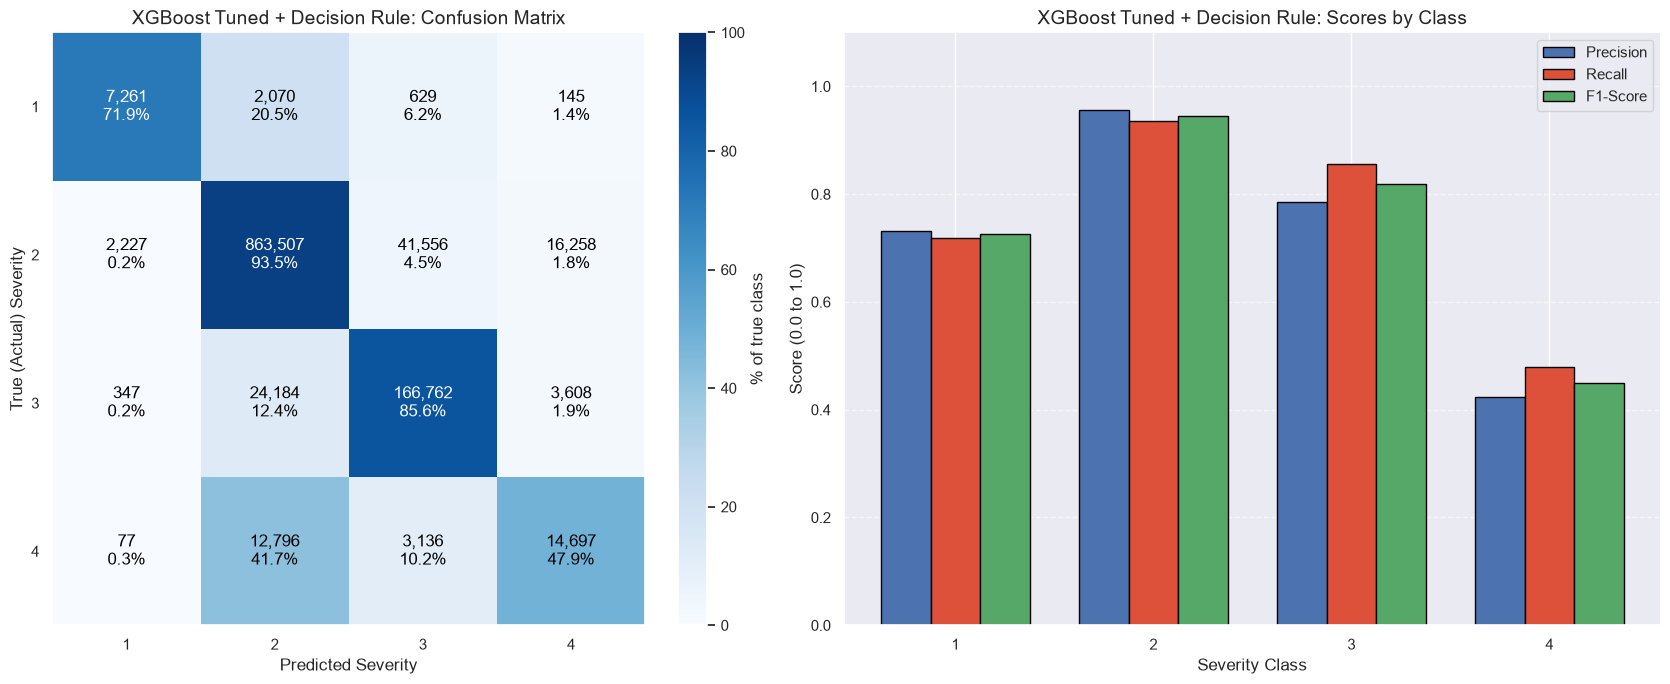

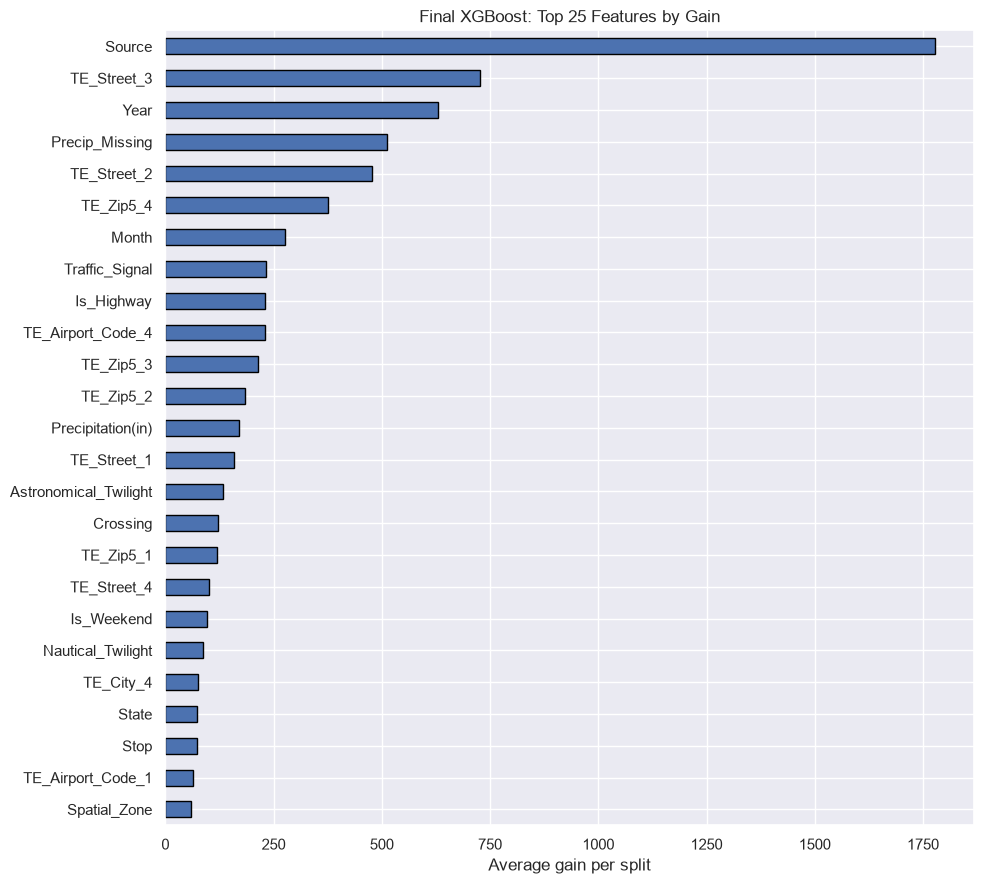

In [64]:
plot_results(y_test, y_pred_final, "XGBoost Tuned + Decision Rule")
plot_importance(model_final, "Final XGBoost: Top 25 Features by Gain", top=25)

# 10. Comparing All Models

All scores are on the test set. KNN was scored on a 10,000-row sample of it, so its numbers are less precise than the others.

,test_rows,accuracy,macro_f1,balanced_accuracy,f1_sev1,f1_sev2,f1_sev3,f1_sev4
KNN (100k-row sample),9998,0.8244,0.3808,0.3523,0.1143,0.8979,0.4565,0.0546
Logistic regression,1159260,0.5376,0.3793,0.6966,0.0836,0.6369,0.6148,0.1822
XGBoost baseline,1159260,0.8559,0.5993,0.6933,0.3614,0.9115,0.7471,0.3773
XGBoost + new features,1159260,0.8795,0.6866,0.7840,0.6295,0.9281,0.7746,0.4144
XGBoost + location encoding,1159260,0.8946,0.7023,0.8032,0.6268,0.9377,0.8131,0.4318
XGBoost without Year and Source,1159260,0.8285,0.5667,0.6441,0.3407,0.8942,0.6708,0.3612
XGBoost + location encoding + decision rule,1159260,0.9069,0.7303,0.7503,0.7154,0.9454,0.8178,0.4425
XGBoost without Year and Source + decision rule,1159260,0.8459,0.5753,0.5831,0.3625,0.9067,0.6704,0.3615
XGBoost tuned,1159260,0.8980,0.7129,0.8001,0.6561,0.9398,0.8158,0.4398
XGBoost tuned + decision rule,1159260,0.9077,0.7350,0.7470,0.7255,0.9457,0.8195,0.4494


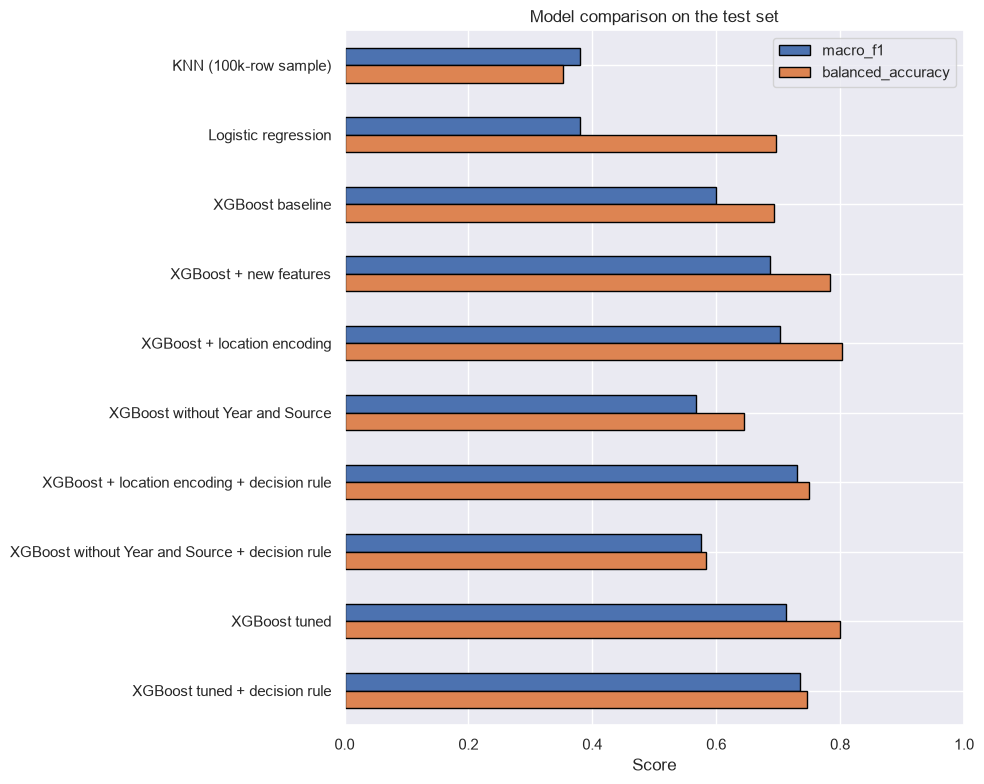

In [65]:
comparison = pd.DataFrame(results).T
comparison["test_rows"] = comparison["test_rows"].astype(int)
display(comparison.round(4))

ax = comparison[["macro_f1", "balanced_accuracy"]].plot.barh(figsize=(10, 0.6 * len(comparison) + 2),
                                                             color=["#4c72b0", "#dd8452"], edgecolor="black")
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("Score"); ax.set_title("Model comparison on the test set")
plt.tight_layout(); plt.show()

In [66]:
best = comparison["macro_f1"].idxmax()
honest = "XGBoost without Year and Source + decision rule"
print(f"Highest macro F1:                 {best} ({comparison.loc[best, 'macro_f1']:.4f})")
print(f"Best score without Year/Source:   {honest} ({comparison.loc[honest, 'macro_f1']:.4f})")
print(f"XGBoost baseline:                 {comparison.loc['XGBoost baseline', 'macro_f1']:.4f}")
print(f"Logistic regression:              {comparison.loc['Logistic regression', 'macro_f1']:.4f}")

Highest macro F1:                 XGBoost tuned + decision rule (0.7350)
Best score without Year/Source:   XGBoost without Year and Source + decision rule (0.5753)
XGBoost baseline:                 0.5993
Logistic regression:              0.3793


# 11. Notes and Limits

- **Year and Source.** Section 9.4 shows how much of the score depends on these two columns. If the gap is large, quote the score without them as the realistic one: it is the score that would carry over to a new data provider or a future year.
- **Random split.** Accidents from the same period and place appear in both the training and the test data. Training on earlier years and testing on later years would be a stricter test.
- **Severity 4.** Check its row in the confusion matrices. In earlier runs it was the hardest class, with many of these accidents predicted as Severity 2.
- **Decision rule.** The multipliers are chosen to raise macro F1, and balanced accuracy may fall as a result. Which score matters more depends on whether missing a severe accident or raising a false alarm is more costly.
- **KNN and logistic regression** were trained on samples to keep the run time reasonable.
- **Validation set.** It was used for early stopping, the decision rule and the settings search. The test set was used only for the final scores.